In [28]:
from collections.abc import Mapping
from pathlib import Path
from typing import cast

import matplotlib
import matplotlib.pyplot as plt
import torch
from lightning.pytorch import seed_everything
from shimmer.modules.global_workspace import GlobalWorkspaceFusion
from shimmer.modules.selection import SelectionBase
from shimmer_ssd import DEBUG_MODE, PROJECT_DIR
from shimmer_ssd.config import DomainModuleVariant, LoadedDomainConfig, load_config
from shimmer_ssd.dataset.pre_process import TokenizeCaptions
from shimmer_ssd.logging import batch_to_device
from shimmer_ssd.modules.domains import load_pretrained_domains
from shimmer_ssd.modules.domains.visual import VisualLatentDomainModule
from tokenizers.implementations.byte_level_bpe import ByteLevelBPETokenizer
from torchvision.utils import make_grid
from torch.utils.data import default_collate

from simple_shapes_dataset import SimpleShapesDataModule, get_default_domains



In [29]:

from shimmer.modules.domain import DomainModule
from shimmer.modules.global_workspace import GlobalWorkspace2Domains, SchedulerArgs

from shimmer_ssd.config import DomainModuleVariant, LoadedDomainConfig, load_config

from shimmer_ssd.modules.domains import load_pretrained_domains

from simple_shapes_dataset import SimpleShapesDataModule, get_default_domains

# %matplotlib inlineKikabosco2

import io
import math
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import torch
from ipywidgets import interact, interact_manual
from PIL import Image
from pathlib import Path
from shimmer_ssd.logging import attribute_image_grid
from shimmer_ssd.config import load_config
from torch.nn.functional import one_hot

from simple_shapes_dataset.cli import generate_image
%matplotlib widget

# And now we load the GW checkpoint
checkpoint_path = Path("./checkpoints")

# We don't use cli in the notebook, but consider using it in normal scripts.
config = load_config("./config", use_cli=False)

config.domain_proportions = {
    frozenset(["v"]): 1.0,
    frozenset(["attr"]): 1.0,
    frozenset(["v", "attr"]): 1.0,
}

config.domains = [
    LoadedDomainConfig(
        domain_type=DomainModuleVariant.v_latents,
        checkpoint_path=checkpoint_path / "domain_v.ckpt",
    ),
    LoadedDomainConfig(
        domain_type=DomainModuleVariant.attr_legacy,
        checkpoint_path=checkpoint_path / "domain_attr.ckpt",
        args = {"alpha": 10, "temperature": 1},
    ),
]

config.domain_data_args["v_latents"]["presaved_path"] = "domain_v.npy"
config.global_workspace.latent_dim = 12





In [ ]:
checkpoint = "checkpoints/gw-attr-v-all-paired-data.ckpt"

config.global_workspace.encoders.hidden_dim = 256
config.global_workspace.encoders.n_layers = 2
config.global_workspace.decoders.hidden_dim = 256
config.global_workspace.decoders.n_layers = 2
# we load the pretrained domain modules and define the associated GW encoders and decoders
domain_modules, gw_encoders, gw_decoders = load_pretrained_domains(
    config.domains,
    config.global_workspace.latent_dim,
    config.global_workspace.encoders.hidden_dim,
    config.global_workspace.encoders.n_layers,
    config.global_workspace.decoders.hidden_dim,
    config.global_workspace.decoders.n_layers,
)
global_workspace = GlobalWorkspace2Domains.load_from_checkpoint(
    checkpoint,
    domain_mods=domain_modules,
    gw_encoders=gw_encoders,
    gw_decoders=gw_decoders,
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_workspace.to(device)




RuntimeError: Error(s) in loading state_dict for GlobalWorkspace2Domains:
	Missing key(s) in state_dict: "gw_mod.gw_decoders.attr.decoder.0.weight", "gw_mod.gw_decoders.attr.decoder.0.bias", "gw_mod.gw_decoders.attr.decoder.2.weight", "gw_mod.gw_decoders.attr.decoder.2.bias", "gw_mod.gw_decoders.attr.decoder_categories.0.weight", "gw_mod.gw_decoders.attr.decoder_categories.0.bias", "gw_mod.gw_decoders.attr.decoder_attributes.0.weight", "gw_mod.gw_decoders.attr.decoder_attributes.0.bias", "loss_mod.gw_mod.gw_decoders.attr.decoder.0.weight", "loss_mod.gw_mod.gw_decoders.attr.decoder.0.bias", "loss_mod.gw_mod.gw_decoders.attr.decoder.2.weight", "loss_mod.gw_mod.gw_decoders.attr.decoder.2.bias", "loss_mod.gw_mod.gw_decoders.attr.decoder_categories.0.weight", "loss_mod.gw_mod.gw_decoders.attr.decoder_categories.0.bias", "loss_mod.gw_mod.gw_decoders.attr.decoder_attributes.0.weight", "loss_mod.gw_mod.gw_decoders.attr.decoder_attributes.0.bias". 
	Unexpected key(s) in state_dict: "gw_mod.doma

In [21]:
def custom_collate_factory(exclude_colors: bool):
    """Returns a collate function that optionally removes color info."""
    if not exclude_colors:
        return default_collate

    def custom_collate(batch):
        """Collate function that removes the last 3 attrs (assumed colors)."""
        result = default_collate(batch)
        # Check if we need to modify the second tensor in attr list
        if (isinstance(result, dict) and "attr" in result and
            isinstance(result["attr"], list) and len(result["attr"]) >= 2 and
            isinstance(result["attr"][1], torch.Tensor) and result["attr"][1].size(-1) >= 4):
            # Remove the last 3 values from the tensor
            result["attr"][1] = result["attr"][1][..., :-3]
        return result
    return custom_collate

domain_classes = get_default_domains(["v_latents", "attr"])
config.dataset.path = "./simple_shapes_dataset"
data_module = SimpleShapesDataModule(
    config.dataset.path,
    domain_classes,
    config.domain_proportions,
    config.training.batch_size,
    seed=config.seed,
    domain_args=config.domain_data_args,
    collate_fn=custom_collate_factory(exclude_colors=False),
)

train_samples = data_module.get_samples("train", 32)
train_samples = batch_to_device(train_samples, device)



In [22]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])
train_paired_samples = train_samples[frozenset(["v_latents", "attr"])]
train_images = visual_module.decode_images(train_paired_samples["v_latents"])


unimodal_latents = global_workspace.encode_domains(train_samples)
gw_latents = global_workspace.encode(unimodal_latents)
gw_latents_decoded = global_workspace.decode(gw_latents[frozenset({'attr'})], ["v_latents"])

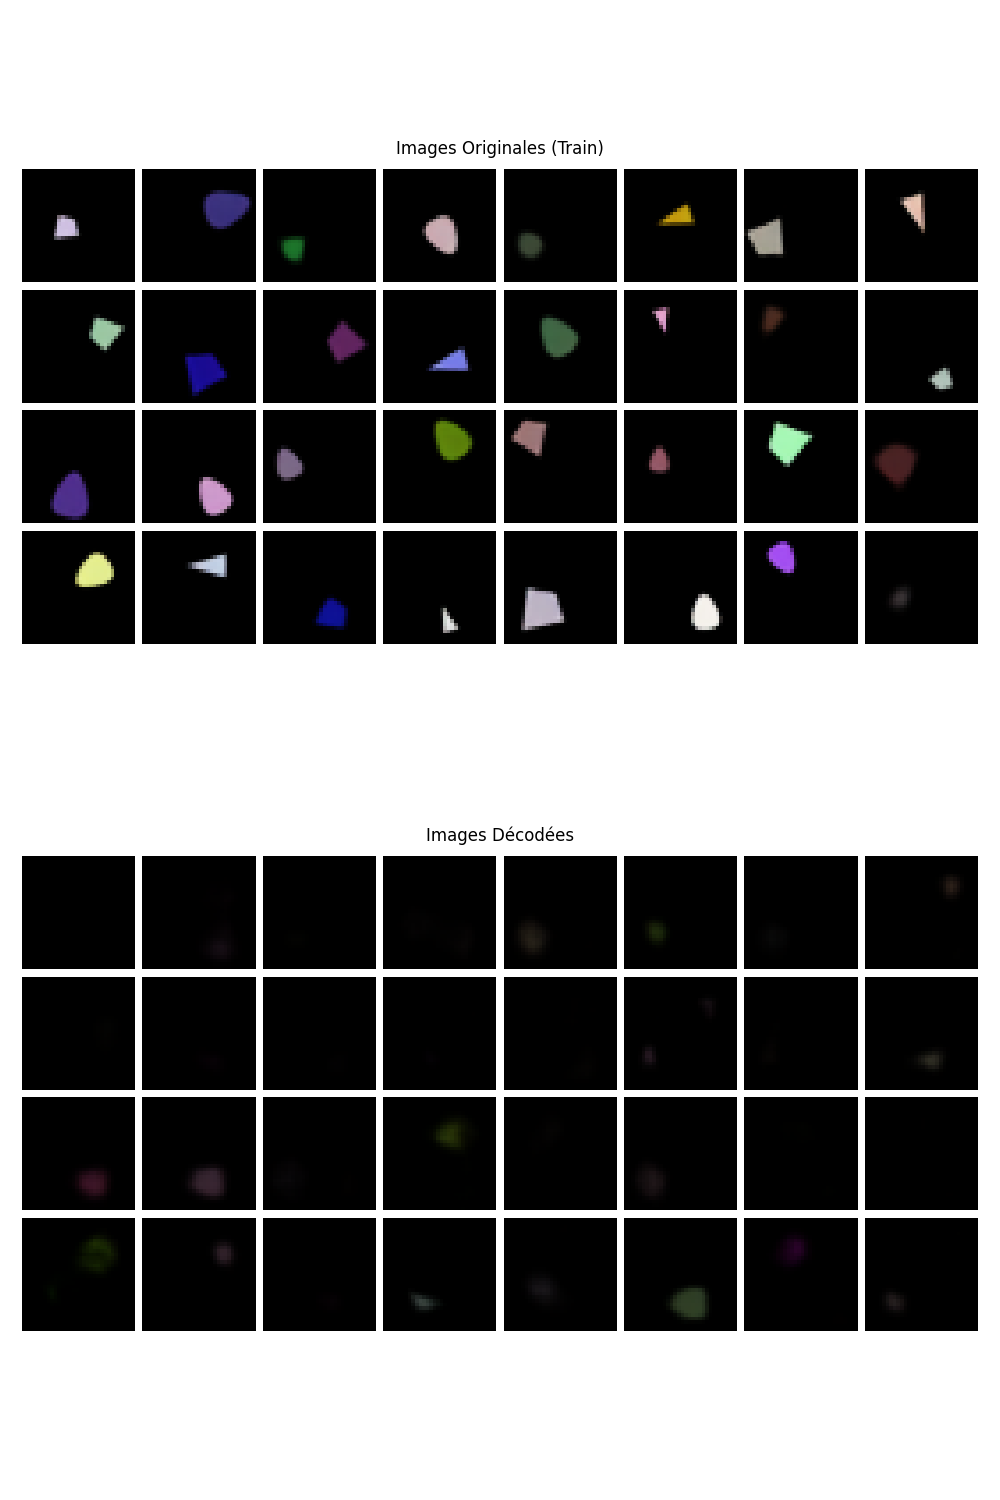

In [23]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

decoded_images = visual_module.decode_images(gw_latents_decoded['attr']['v_latents'])

def get_grid_numpy(samples, nrow=8):
    """Transforme les samples en grille numpy prête pour l'affichage"""
    grid = make_grid(samples, nrow=nrow, pad_value=1).permute(1, 2, 0)
    return grid.detach().cpu().numpy()

# 1. Préparation des données
grid_train = get_grid_numpy(train_images)
grid_decoded = get_grid_numpy(decoded_images)

# 2. Création d'une figure avec 2 lignes (subplots)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 15))

# Affichage sur le premier axe (Haut)
ax1.imshow(grid_train)
ax1.set_title("Images Originales (Train)")
ax1.axis('off') # Enlève les bordures de pixels

# Affichage sur le second axe (Bas)
ax2.imshow(grid_decoded)
ax2.set_title("Images Décodées")
ax2.axis('off')

plt.tight_layout() # Ajuste l'espacement automatiquement
plt.show()

In [ ]:
%matplotlib widget
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
global_workspace.to(device)

cat2idx = {"Diamond": 0, "Egg": 1, "Triangle": 2}


def get_image(cat, x, y, size, rot, color_r, color_g, color_b):
    fig, ax = plt.subplots(figsize=(32, 32), dpi=1)
    # The dataset generatoion tool has function to generate a matplotlib shape
    # from the attributes. 
    generate_image(
        ax,
        cat2idx[cat],
        [int(x * 18 + 7), int(y * 18 + 7)],
        size * 7 + 7,
        rot * 2 * math.pi,
        np.array([color_r * 255, color_g * 255, color_b * 255]),
        imsize=32,
    )
    ax.set_facecolor("black")
    plt.tight_layout(pad=0)
    # Return this as a PIL Image.
    # This is to have the same dpi as saved images
    # otherwise matplotlib will render this in very high quality
    buf = io.BytesIO()
    fig.savefig(buf)
    buf.seek(0)
    image = Image.open(buf)
    plt.close(fig)
    return image


@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    fig, axes = plt.subplots(1, 2)
    image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    axes[0].set_facecolor("black")
    axes[0].set_title("Original image from attributes")
    axes[0].set_xticks([])
    axes[0].set_yticks([])
    axes[0].imshow(image)

    # normalize the attribute for the global workspace.
    category = one_hot(torch.tensor([cat2idx[cat]]), 3)
    rotx = math.cos(rot * 2 * math.pi)
    roty = math.sin(rot * 2 * math.pi)
    attributes = torch.tensor(
        [[x * 2 - 1, y * 2 - 1, size * 2 - 1, rotx, roty, color_r * 2 - 1, color_g * 2 - 1, color_b * 2 - 1]]
    )
    samples = [category.to(device), attributes.to(device)]
    attr_gw_latent = global_workspace.gw_mod.encode({"attr": global_workspace.encode_domain(samples, "attr")})
    gw_latent = global_workspace.gw_mod.fuse(
        attr_gw_latent, {"attr": torch.ones(attr_gw_latent["attr"].size(0)).to(device)}
    )
    decoded_latents = global_workspace.gw_mod.decode(gw_latent)["v_latents"]
    decoded_images = (
        global_workspace.domain_mods["v_latents"]
        .decode_images(decoded_latents)[0]
        .permute(1, 2, 0)
        .detach()
        .cpu()
        .numpy()
    )
    axes[1].imshow(decoded_images)
    axes[1].set_xticks([])
    axes[1].set_yticks([])
    axes[1].set_title("Translated image through GW")
    plt.show()


interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…